In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

In [2]:
# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

In [3]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths)

In [4]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
#print("\nFiltered files:")
#print(filtered_files)


In [5]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_dry_neph)

In [6]:
# Initialize a list to store file paths
file_paths_flight_sum = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/flight-sum*.txt"
    file_paths_flight_sum.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_flight_sum)

In [7]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_sp2)

In [8]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_ams)

In [9]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}
flights_neph = {extract_flight_number(f) for f in file_paths_dry_neph}
flights_sum = {extract_flight_number(f) for f in file_paths_flight_sum}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in file_paths_dry_neph if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in file_paths_flight_sum if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [10]:
common_flights

{'b734',
 'b737',
 'b739',
 'b740',
 'b741',
 'b742',
 'b743',
 'b744',
 'b745',
 'b746',
 'b747',
 'b748',
 'b749',
 'b750'}

In [10]:
filtered_nc[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_nc[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

20120918


In [11]:
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("datetime", datetime_values))
    dsf["Times"] = (("time",), datetime_values)

    return dsf

In [12]:
def dataset_neph(file_path_neph):

    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds_neph

In [13]:
ds_C0 = xr.open_dataset(filtered_nc[0])
ds_C0

<xarray.Dataset> Size: 281MB
Dimensions:         (data_point: 25820, sps32: 32, sps04: 4, sps01: 1,
                     sps02: 2, sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/141)
    Time            (data_point) datetime64[ns] 207kB ...
    IAS_RVSM        (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAS_RVSM        (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAT_DI_R        (data_point, sps32) float32 3MB ...
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 103kB ...
    TDEW_C_U_FLAG   (data_point, sps01) float32 103kB ...
    U_NOTURB        (data_point, sps01) float32 103kB ...
    U_NOTURB_FLAG   (data_point, sps01) float32 103kB ...
    V_NOTURB        (data_point, sps01) float32 103kB ...
    V_NOTURB_FLAG   (data_point, sps01) float32 103kB ...
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

In [14]:
ds_CO_resampled = ds_C0.resample(Time="1min").mean()

In [15]:
valid_CO = ds_CO_resampled["CO_AERO_FLAG"] == 0
filtered_CO = ds_CO_resampled.where(valid_CO, drop=True)

In [16]:
filtered_CO

<xarray.Dataset> Size: 2MB
Dimensions:         (data_point: 228, sps32: 32, sps01: 1, sps04: 4, sps02: 2,
                     sps64: 64)
Coordinates:
  * data_point      (data_point) datetime64[ns] 2kB 2012-09-18T10:26:00 ... 2...
Dimensions without coordinates: sps32, sps01, sps04, sps02, sps64
Data variables: (12/140)
    IAS_RVSM        (data_point, sps32, sps01) float32 29kB 0.0 0.0 ... 67.19
    IAS_RVSM_FLAG   (data_point, sps32, sps01) float32 29kB 3.0 3.0 ... 0.0 0.0
    TAS_RVSM        (data_point, sps32, sps01) float32 29kB 0.0 0.0 ... 70.01
    TAS_RVSM_FLAG   (data_point, sps32, sps01) float32 29kB 3.0 3.0 ... 0.0 0.0
    TAT_DI_R        (data_point, sps32, sps01) float32 29kB 0.0 0.0 ... 303.9
    TAT_DI_R_FLAG   (data_point, sps32, sps01) float32 29kB 3.0 3.0 ... 0.0 0.0
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 912B nan nan ... 0.3587 0.3582
    TDEW_C_U_FLAG   (data_point, sps01) float32 912B 3.0 3.0 3.0 ... 0.0 0.0 0.0
    U_NOTURB        (data_point, sps01) float32 912B nan nan nan ... 1.401 2.117
    U_NOTURB_FLAG   (data_point, sps01) float32 912B 3.0 3.0 3.0 ... 2.7 1.15
    V_NOTURB        (data_point, sps01) float32 912B nan nan ... -3.222 -2.975
    V_NOTURB_FLAG   (data_point, sps01) float32 912B 3.0 3.0 3.0 ... 2.7 1.15
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

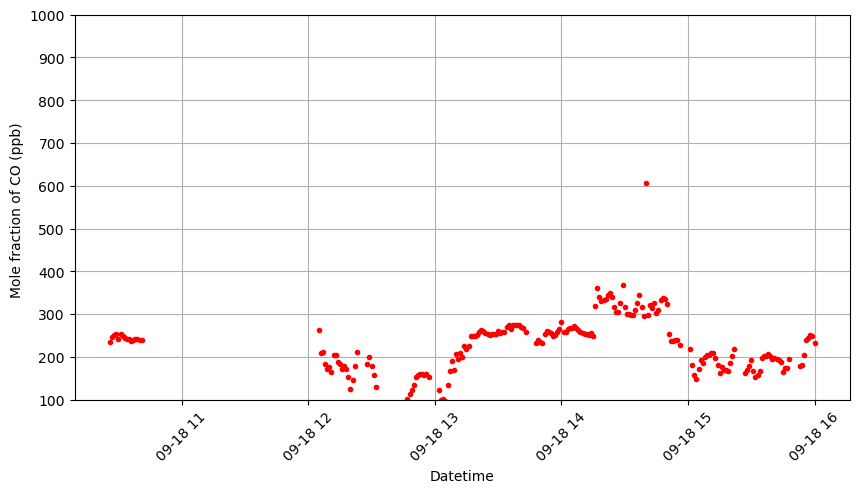

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(filtered_CO['data_point'].squeeze(), filtered_CO['CO_AERO'], color="r", marker='.',linewidth=0)
#plt.xlim(filtered_ds_psap['Time'][550],filtered_ds_psap['Time'][3000])
plt.ylim(100,1000)
# Formatting
plt.xlabel("Datetime")
plt.ylabel("Mole fraction of CO (ppb) ")
#plt.title("Mass absortion efficiency Over Time")
plt.xticks(rotation=45)
plt.grid()

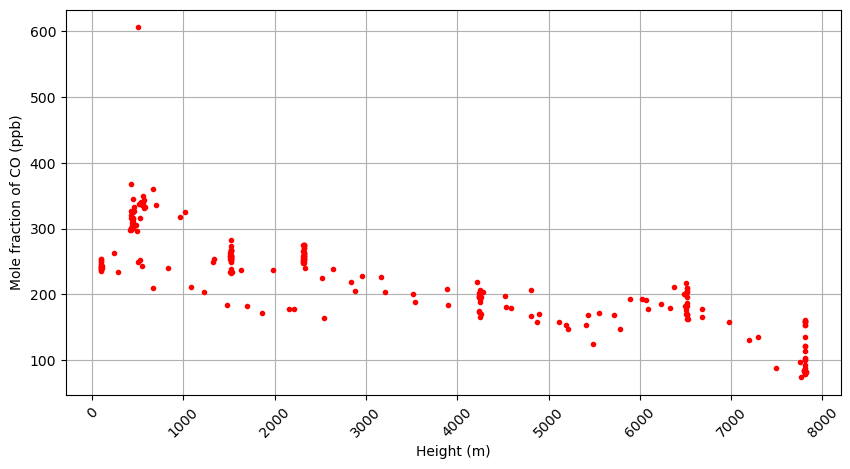

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(filtered_CO['GPS_ALT'], filtered_CO['CO_AERO'], color="r", marker='.',linewidth=0)
#plt.xlim(filtered_ds_psap['Time'][550],filtered_ds_psap['Time'][3000])
#plt.ylim(100,1000)
# Formatting
plt.ylabel("Mole fraction of CO (ppb)")
plt.xlabel("Height (m)")
#plt.title("Mass absortion efficiency Over Time")
plt.xticks(rotation=45)
plt.grid()

In [170]:
ds_neph = dataset_neph(filtered_neph[0])

In [24]:
def parse_flight_log(lines):
    extracted_data = []
    
    for line in lines[2:]:  # Skip headers
        parts = re.split(r'\s{2,}', line.strip())  # Split on 2+ spaces
        
        if len(parts) < 2:
            continue  # Skip lines with insufficient data
        
        start_time = parts[0]  # First column is always Start Time

        # Check if second column is numeric (End Time), if so, event is at index 2
        if len(parts) > 2 and parts[1].isdigit():
            event = parts[2]  # Third column is the event
        else:
            event = parts[1]  # Otherwise, second column is the event

        extracted_data.append([start_time, event])  # Append as list (not tuple)
        
    return np.array(extracted_data)  # Convert to NumPy array

In [25]:
def flight_comments_df(file_path_flight_comm):
    # Read the file
    with open(file_path_flight_comm, "r") as file:
        lines = file.readlines()
    # Process and print output
    parsed_data = parse_flight_log(lines)
    
    start_time_col = parsed_data[3:, 0]  # First column
    event_col = parsed_data[3:, 1]  # Second column

    # Create DataFrame
    df_flight = pd.DataFrame({"Start Time": start_time_col, "Event": event_col})

    
    return df_flight

In [26]:
# Read the file
with open(filtered_sum[0], "r") as file:
    lines = file.readlines()
# Process and print output
parsed_data = parse_flight_log(lines)

start_time_col = parsed_data[3:, 0]  # First column
event_col = parsed_data[3:, 1]  # Second column

# Create DataFrame
df_flight = pd.DataFrame({"Start Time": start_time_col, "Event": event_col})

# Print the DataFrame
#print(df_flight)

In [27]:
# Assuming df is your DataFrame and has columns "Start Time" and "Event"
start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]

# Print the extracted start time
print(start_up_time)

114944


In [33]:
def plot_co_data_v1(flight_number,flight_date,
                     CO_resampled, df_flight):

    # Step 1: Convert 'Start Time' (HHMMSS) to full datetime for event annotations
    df_flight["Start Time"] = pd.to_datetime(df_flight["Start Time"], format="%H%M%S")
    df_flight["Start Time"] = df_flight["Start Time"].apply(
        lambda t: pd.Timestamp(str(flight_date)) + pd.Timedelta(hours=t.hour, minutes=t.minute, seconds=t.second)
    )
    start_up_time = df_flight[df_flight["Event"] == "Start-Up"]["Start Time"].iloc[0]
    
    # Step 3: Prepare height and time data
    ds_times = CO_resampled["data_point"].values  # Time from dataset
    height_values = CO_resampled["GPS_ALT"].values[:, 0]  # Assuming shape (time, sps)
    
    # Step 4: Create the figure with 2 separate subplots
    fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8), sharex=True)

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    
    # Time formatter to show HH:MM
    time_formatter = mdates.DateFormatter('%H:%M')
    
    
    # --- First Plot: Scattering colored by RH ---
    ax1.scatter(CO_resampled['data_point'].squeeze(), CO_resampled['CO_AERO'], color="r", marker='.',linewidth=0)
    ax1.set_ylabel(r'Mole fraction of CO (ppb)')
    ax1.set_ylim(0,1000)
    ax1.yaxis.set_major_formatter(formatter)
    ax1.grid(True)
    ax1.set_title(f"Flight {flight_number} - Date: {flight_date}")
    # --- Second Plot: Height over time with event labels ---
    ax2.plot(ds_times, height_values, color="b", label="Height")
    
    for event_time, event_name in zip(df_flight["Start Time"], df_flight["Event"]):
        closest_idx = np.argmin(np.abs(ds_times - np.datetime64(event_time)))
        closest_time = ds_times[closest_idx]
        height_at_time = height_values[closest_idx]
        ax2.text(closest_time, height_at_time, event_name, fontsize=6, color="red", ha="left", va="bottom", rotation=45)
    
    ax2.set_ylabel("Height (m)")
    #ax2.set_title("Flight Profile with Annotated Events")
    # Right-side title using a twin axis
    ax2_right = ax2.twinx()  # Create a twin y-axis sharing the same x-axis
    ax2_right.set_ylabel("Flight Profile with Annotated Events", rotation=90, labelpad=30)
    ax2_right.yaxis.set_label_position("right")
    ax2_right.tick_params(right=False, labelright=False)  # Hide ticks and labels
    ax2.grid(True)
    
    # Set time format on x-axis
    ax2.xaxis.set_major_formatter(time_formatter)
    ax2.set_xlim(start_up_time, ds_times[-1])
    
    # Rotate x-axis labels
    plt.xticks(rotation=45)
    
    # Layout
    plt.savefig(f'./CO_plots/CO_{flight_number}_v1.png', dpi=300)
    print(f"Figure saved as CO_{flight_number}_v1.png")
    #plt.show()
    return

Figure saved as CO_b734_v1.png
Figure saved as CO_b737_v1.png
Figure saved as CO_b739_v1.png
Figure saved as CO_b740_v1.png
Figure saved as CO_b741_v1.png
Figure saved as CO_b742_v1.png
Figure saved as CO_b743_v1.png
Figure saved as CO_b744_v1.png
Figure saved as CO_b745_v1.png
Figure saved as CO_b746_v1.png
Figure saved as CO_b747_v1.png
Figure saved as CO_b748_v1.png
Figure saved as CO_b749_v1.png
Figure saved as CO_b750_v1.png


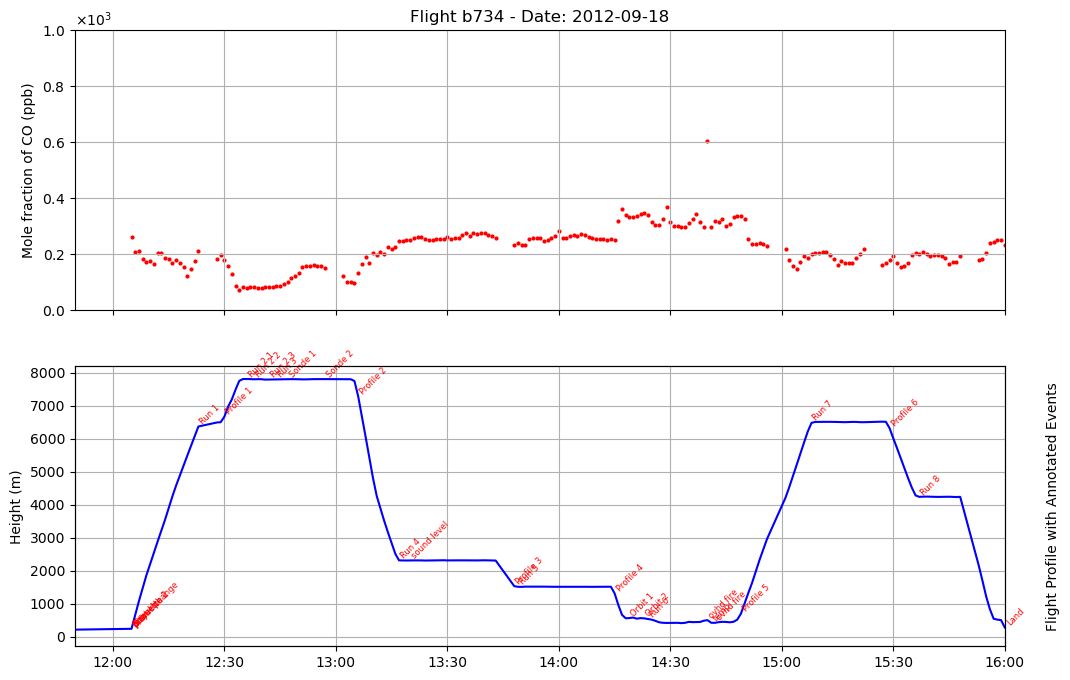

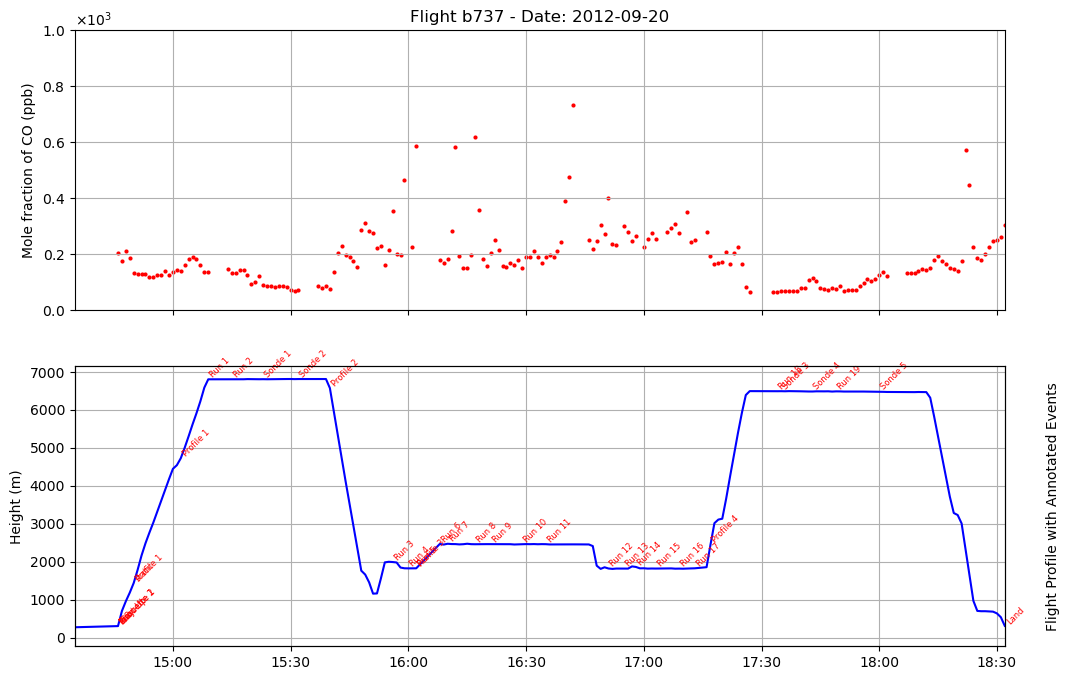

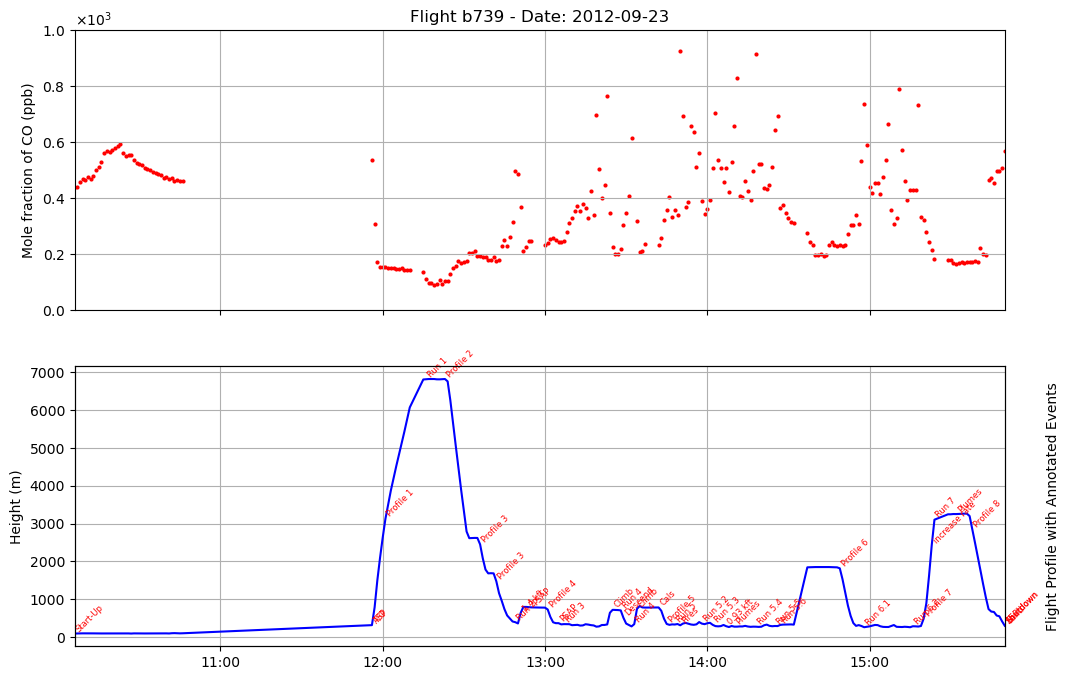

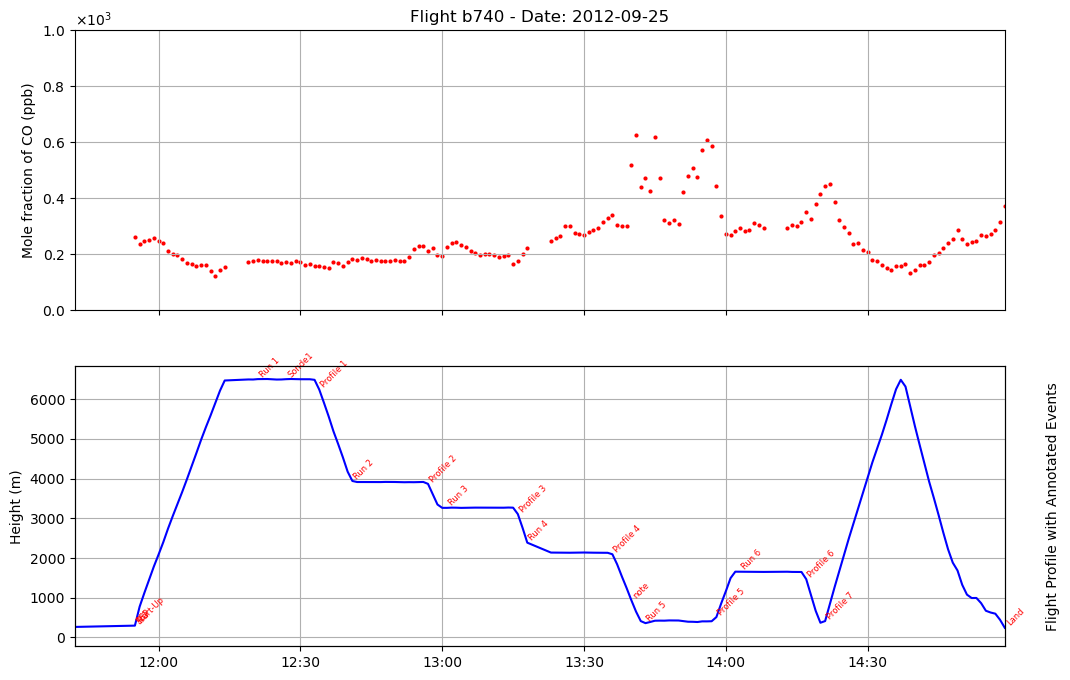

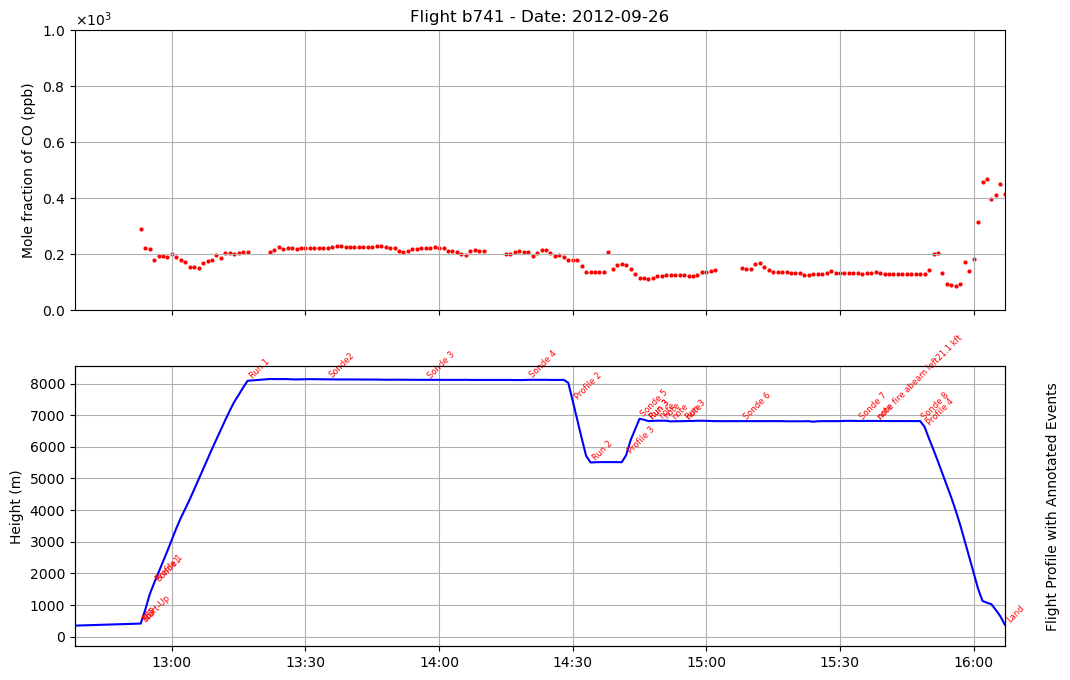

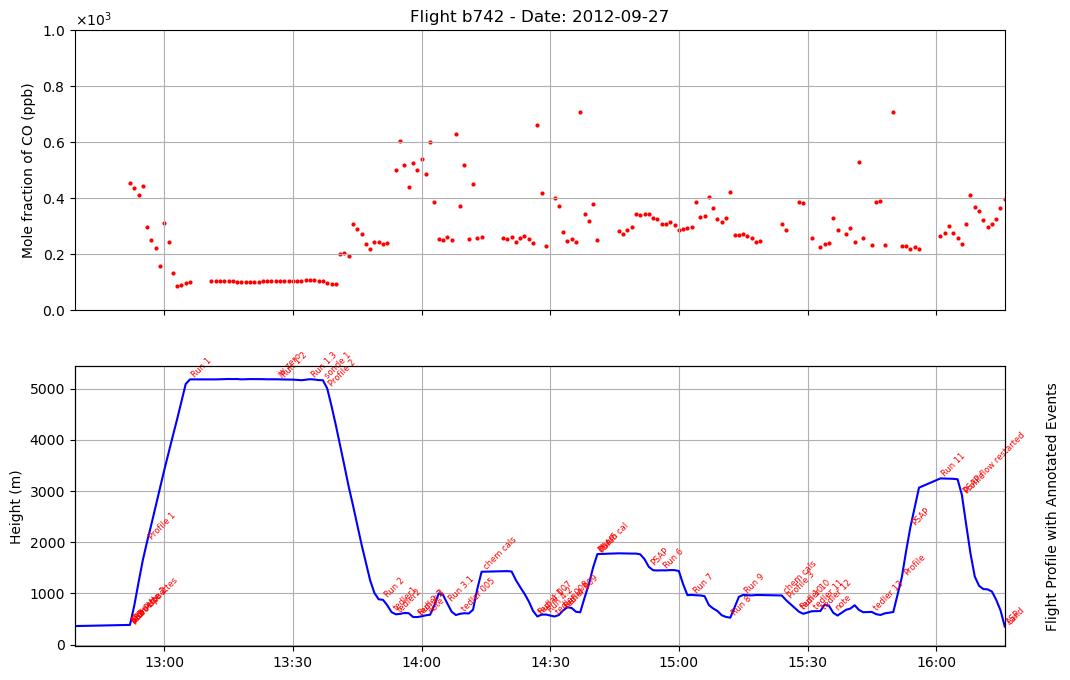

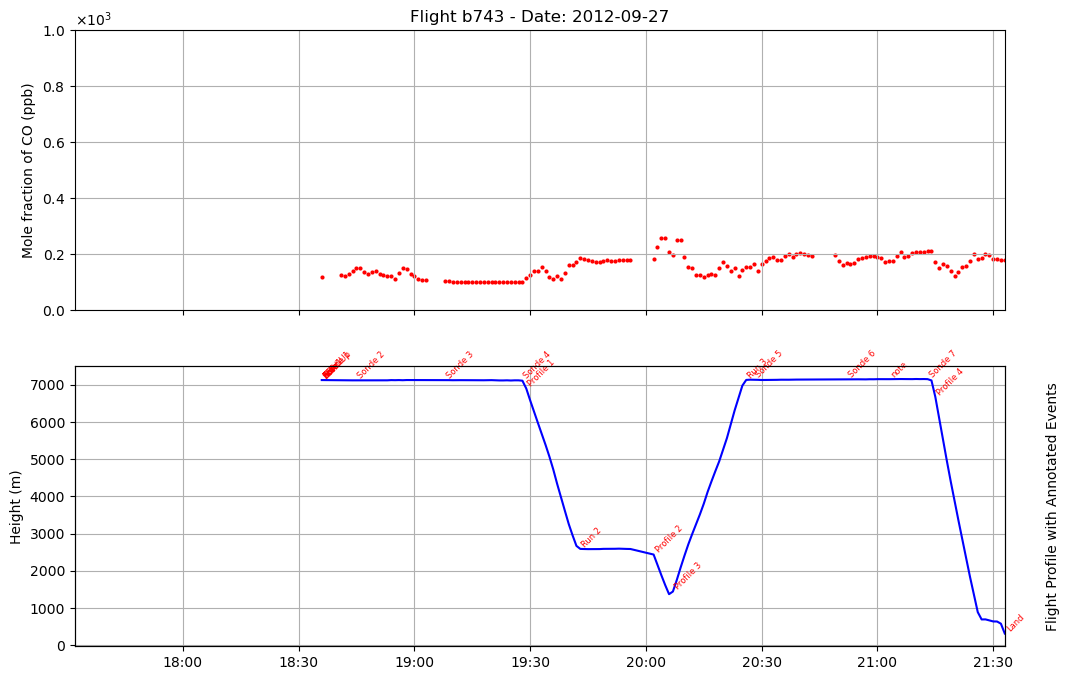

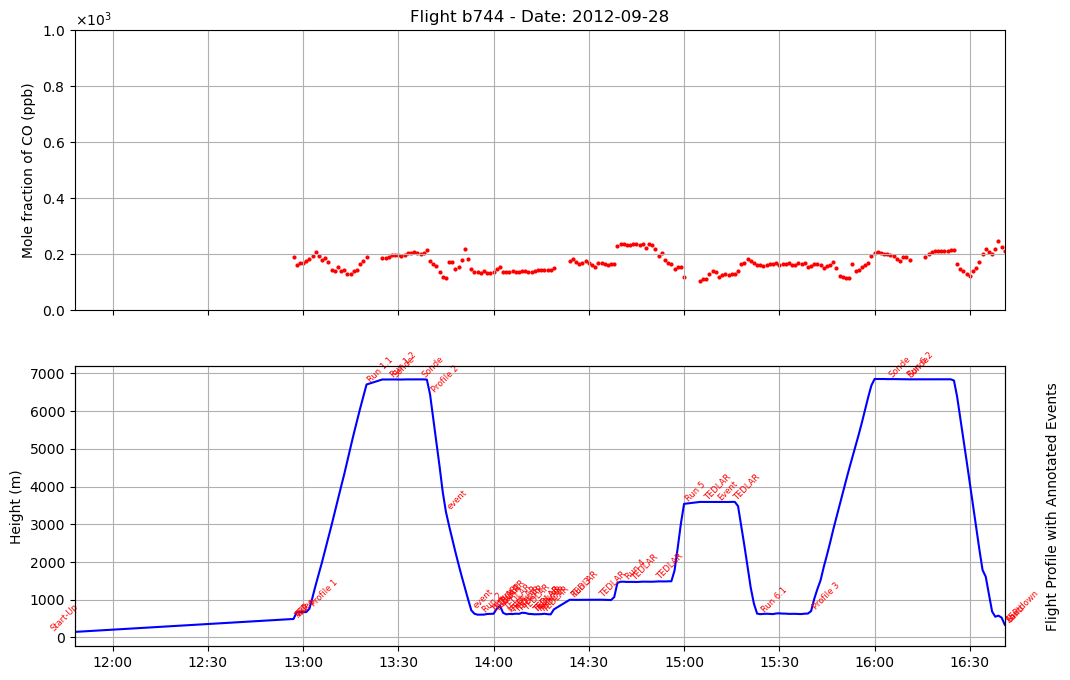

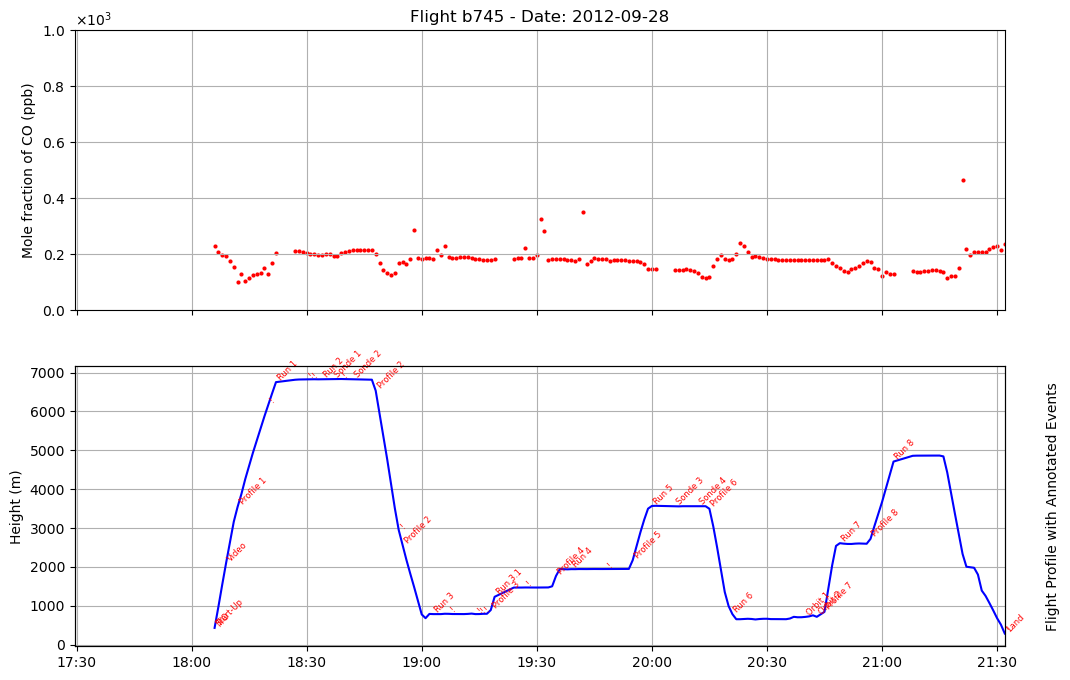

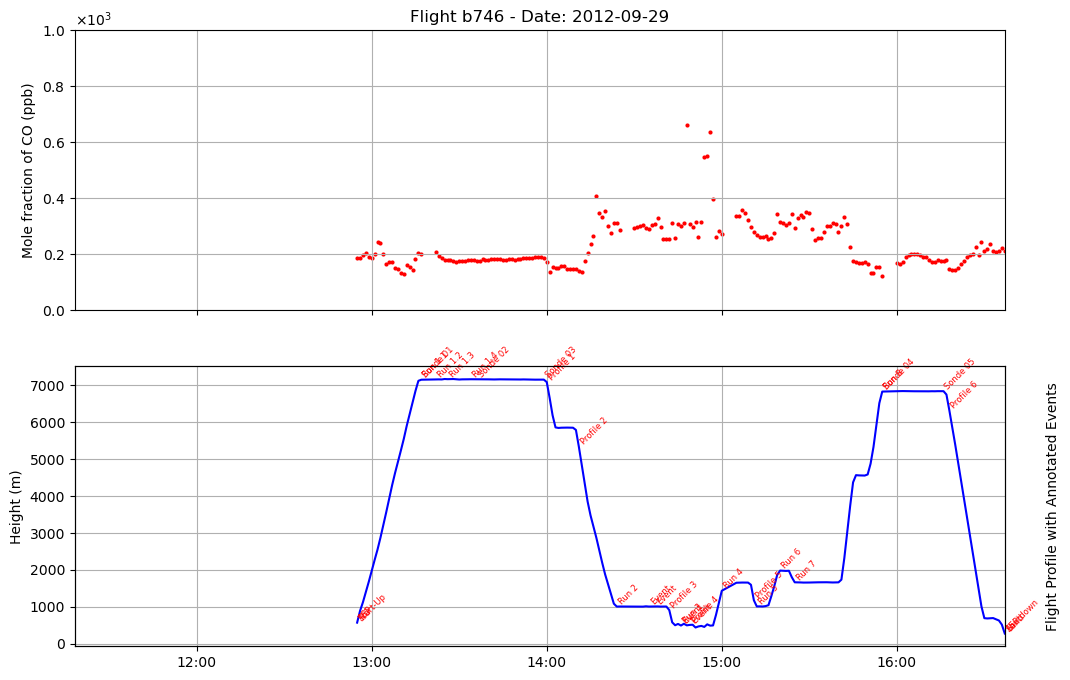

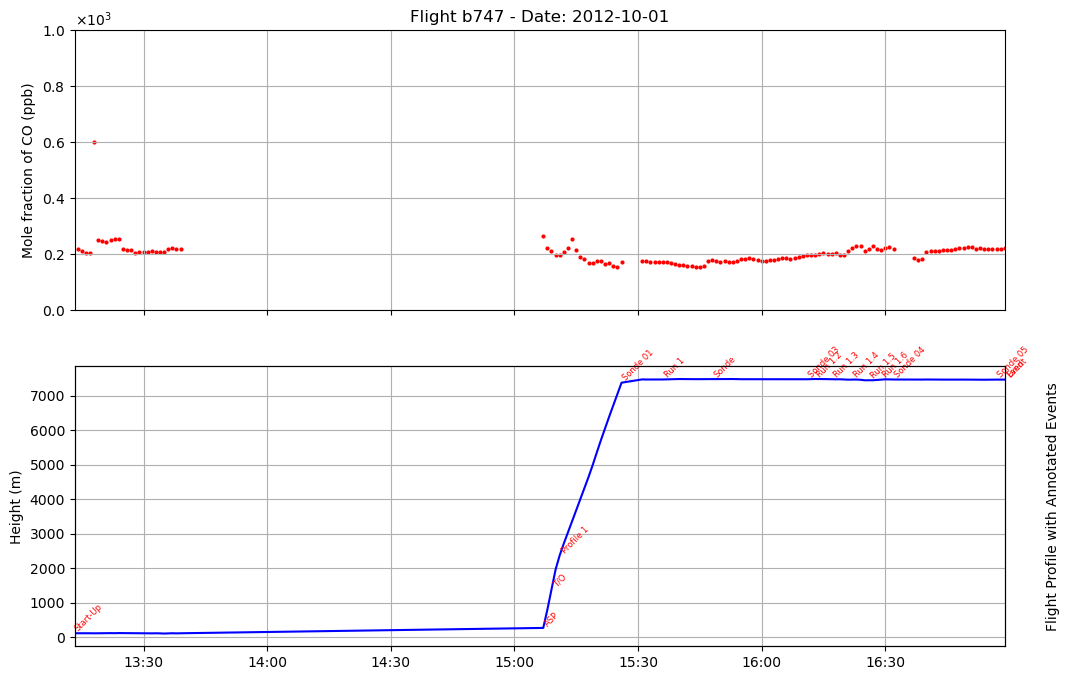

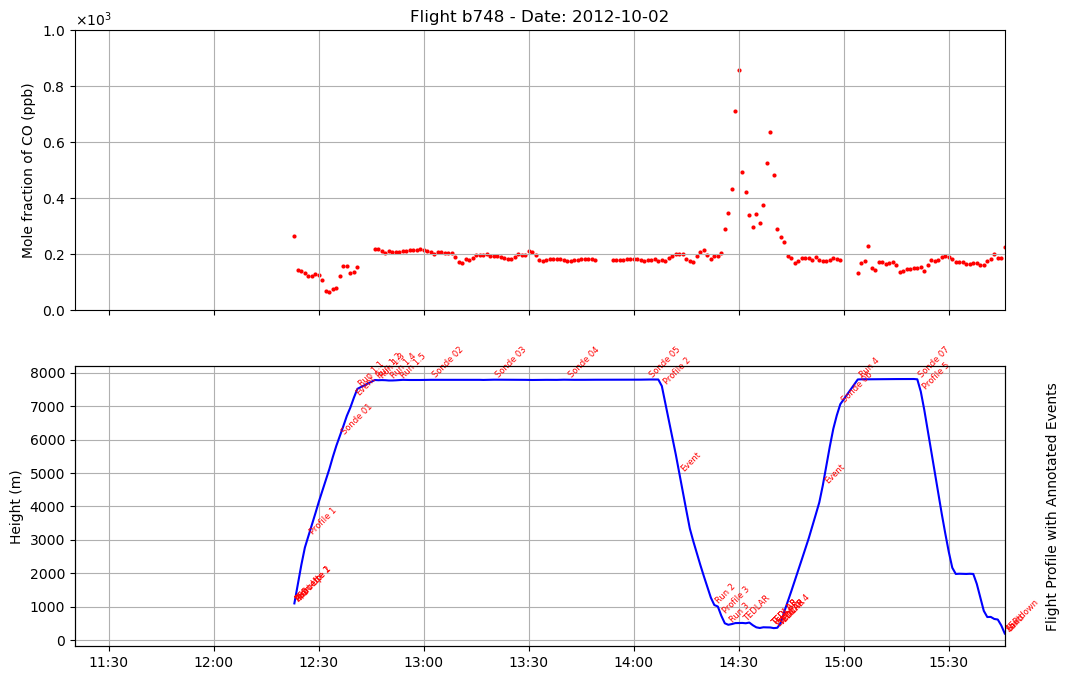

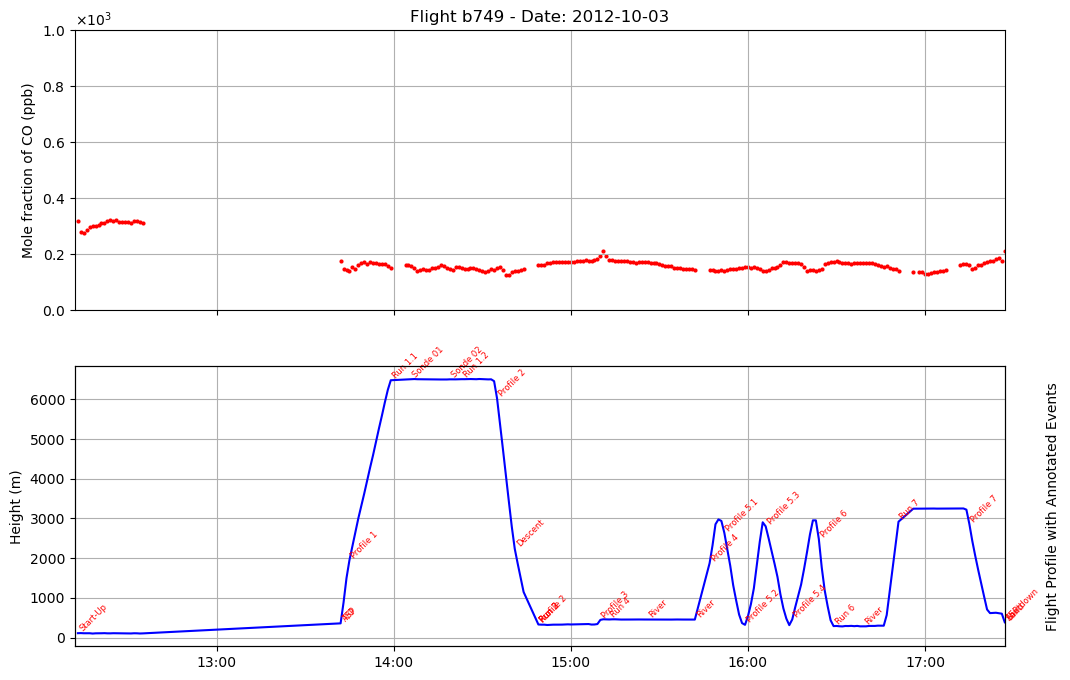

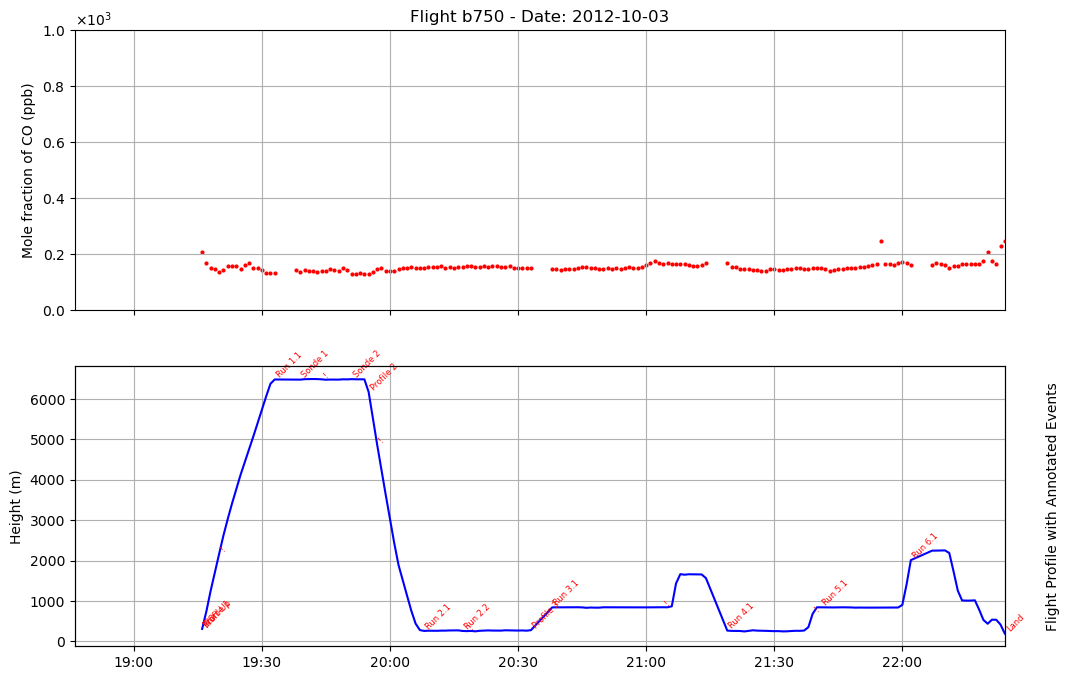

In [34]:
# List to store results
results = []



# Iterate over all matching flights
for nc_file, neph_file, flight_comments_file in zip(filtered_nc, filtered_neph,filtered_sum):

    #print(neph_file)
    ds_C0 = xr.open_dataset(nc_file)
    ds_CO_resampled = ds_C0.resample(Time="1min").mean()
    valid_CO = ds_CO_resampled["CO_AERO_FLAG"] == 0
    filtered_CO = ds_CO_resampled.where(valid_CO, drop=True)

    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    # Extract the date in yyyymmdd format
    date_match = re.search(r'(\d{8})', nc_file)
    if date_match:
        date_str = date_match.group(1)
        flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
    else:
        flight_date = "Unknown"
    
    #print(flight_date)
    #Flight comments dataset
    df_flight = flight_comments_df(flight_comments_file)

    plot_co_data_v1( 
        flight_number=flight_number,
        flight_date = flight_date,
        CO_resampled=filtered_CO,
        df_flight=df_flight)
    